In [1]:
# 06_merge_and_clean_data.ipynb
# Merge combine with draft AV

import pandas as pd
import numpy as np
from pathlib import Path

# Directories
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load cleaned college production dataset
college_df = pd.read_csv(PROCESSED_DIR / "college_all_positions_clean.csv")

# Load draft picks dataset (contains dr_av)
draft_df = pd.read_csv(RAW_DIR / "draft_picks.csv")

print("College shape:", college_df.shape)
print("Draft shape:", draft_df.shape)

College shape: (2321, 48)
Draft shape: (2544, 36)


In [3]:
print("College columns:")
print(college_df.columns)

print("\nDraft columns:")
print(draft_df.columns)

College columns:
Index(['Player', 'Rate', 'Draft Team', 'Round', 'Pick', 'Draft Year',
       'Draft College', 'From', 'To', 'G', 'qb_Cmp', 'qb_Att', 'qb_Inc',
       'qb_Cmp%', 'qb_Yds', 'qb_TD', 'qb_Int', 'qb_TD%', 'qb_Int%', 'qb_Y/A',
       'qb_AY/A', 'qb_Y/C', 'qb_Y/G', 'Pos', 'Team', 'rb_rush_Y/G',
       'rb_rush_Att', 'rb_rush_Yds', 'rb_rush_Y/A', 'rb_rush_TD', 'rb_rec_Rec',
       'rb_rec_Y/R', 'rb_rec_TD', 'rb_rec_Y/G', 'rec_Y/G', 'rec_Rec',
       'rec_Yds', 'rec_Y/R', 'rec_TD', 'Sk', 'Solo', 'Ast', 'Comb', 'TFL',
       'Sk/G', 'Int', 'IntTD', 'PD'],
      dtype='str')

Draft columns:
Index(['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 

In [4]:
draft_subset = draft_df[["season", "pick", "dr_av"]].copy()

draft_subset = draft_subset.rename(columns={
    "season": "Draft Year",
    "pick": "Pick"
})

draft_subset.head()

,Draft Year,Pick,dr_av
0,2011,1,107.0
1,2011,2,97.0
2,2011,3,47.0
3,2011,4,71.0
4,2011,5,95.0


In [5]:
# Check duplicate (Draft Year, Pick)
duplicates = college_df.duplicated(subset=["Draft Year", "Pick"], keep=False)

dup_df = college_df[duplicates].sort_values(["Draft Year", "Pick"])

print("Number of duplicate rows:", dup_df.shape[0])
dup_df[["Player", "Draft Year", "Pick", "Team"]].head(20)

Number of duplicate rows: 255


,Player,Draft Year,Pick,Team
10,J.J. Watt,2011,11,Central Michigan
11,J.J. Watt,2011,11,Wisconsin
17,Nate Solder,2011,17,Colorado
18,Nate Solder,2011,17,Colorado
58,Greg Little,2011,59,North Carolina
59,Greg Little,2011,59,North Carolina
64,Randall Cobb,2011,64,Kentucky
65,Randall Cobb,2011,64,Kentucky
67,Dontay Moch,2011,66,Nevada
68,Dontay Moch,2011,66,Nevada


In [6]:
# only keep last college season for duplicates (multiple colleges)

college_df = college_df.sort_values(
    ["Draft Year", "Pick", "To"]
).drop_duplicates(
    subset=["Draft Year", "Pick"],
    keep="last"
)

In [7]:
merged_df = college_df.merge(
    draft_subset,
    on=["Draft Year", "Pick"],
    how="left"
)

In [8]:
merged_df.duplicated(["Draft Year", "Pick"]).sum()

np.int64(0)

In [9]:
print("Missing dr_av:", merged_df["dr_av"].isna().sum())

Missing dr_av: 288


In [10]:
print("Before drop:", merged_df.shape)
merged_df = merged_df.dropna(subset=["dr_av"])
print("After drop:", merged_df.shape)

Before drop: (2192, 49)
After drop: (1904, 49)


In [11]:
merged_df["Pos"].value_counts()

Pos
DB    317
DL    272
WR    261
LB    255
OL    195
RB    183
TE    104
QB     84
DE     62
CB     58
DT     38
S      32
T      18
G      10
C       6
FB      5
LS      4
Name: count, dtype: int64

In [14]:
# ---------------------------------
# Create Position Group Column
# ---------------------------------

def map_position(pos):
    if pos == "QB":
        return "QB"
    elif pos in ["RB", "WR", "TE", "FB"]:
        return "Skill"
    elif pos in ["OL", "T", "G", "C"]:
        return "OL"
    elif pos in ["DL", "DE", "DT", "LB"]:
        return "Front7"
    elif pos in ["DB", "CB", "S"]:
        return "DB"
    else:
        return "Other"

merged_df["PosGroup"] = merged_df["Pos"].apply(map_position)

print("Position group counts:")
print(merged_df["PosGroup"].value_counts())

Position group counts:
PosGroup
Front7    627
Skill     553
DB        407
OL        229
QB         84
Other       4
Name: count, dtype: int64


In [15]:
# ---------------------------------
# Split into 5 modeling datasets
# ---------------------------------

qb_df = merged_df[merged_df["PosGroup"] == "QB"].copy()
skill_df = merged_df[merged_df["PosGroup"] == "Skill"].copy()
ol_df = merged_df[merged_df["PosGroup"] == "OL"].copy()
front7_df = merged_df[merged_df["PosGroup"] == "Front7"].copy()
db_df = merged_df[merged_df["PosGroup"] == "DB"].copy()

print("Shapes:")
print("QB:", qb_df.shape)
print("Skill:", skill_df.shape)
print("OL:", ol_df.shape)
print("Front7:", front7_df.shape)
print("DB:", db_df.shape)

Shapes:
QB: (84, 50)
Skill: (553, 50)
OL: (229, 50)
Front7: (627, 50)
DB: (407, 50)


In [16]:
def quick_check(df, name):
    print(f"\n{name} Check")
    print("Rows:", df.shape[0])
    print("Missing dr_av:", df["dr_av"].isna().sum())
    print("Duplicate (Year,Pick):",
          df.duplicated(["Draft Year","Pick"]).sum())
    print("dr_av mean:", round(df["dr_av"].mean(), 2))
    print("dr_av std:", round(df["dr_av"].std(), 2))

quick_check(qb_df, "QB")
quick_check(skill_df, "Skill")
quick_check(ol_df, "OL")
quick_check(front7_df, "Front7")
quick_check(db_df, "DB")


QB Check
Rows: 84
Missing dr_av: 0
Duplicate (Year,Pick): 0
dr_av mean: 24.71
dr_av std: 33.47

Skill Check
Rows: 553
Missing dr_av: 0
Duplicate (Year,Pick): 0
dr_av mean: 11.94
dr_av std: 15.78

OL Check
Rows: 229
Missing dr_av: 0
Duplicate (Year,Pick): 0
dr_av mean: 19.4
dr_av std: 19.63

Front7 Check
Rows: 627
Missing dr_av: 0
Duplicate (Year,Pick): 0
dr_av mean: 15.32
dr_av std: 19.53

DB Check
Rows: 407
Missing dr_av: 0
Duplicate (Year,Pick): 0
dr_av mean: 10.46
dr_av std: 12.62


In [17]:
skill_df.isna().mean().sort_values(ascending=False).head(15)

Rate       1.0
qb_TD%     1.0
qb_Cmp%    1.0
qb_Int     1.0
qb_TD      1.0
qb_Yds     1.0
qb_Att     1.0
qb_Inc     1.0
qb_Cmp     1.0
Comb       1.0
PD         1.0
Ast        1.0
Sk         1.0
qb_Y/G     1.0
qb_Y/C     1.0
dtype: float64

In [18]:
skill_df.groupby("Pos")["dr_av"].mean()

Pos
FB     0.600000
RB    12.765027
TE     8.826923
WR    12.823755
Name: dr_av, dtype: float64

In [19]:
skill_df.groupby("Pos")["dr_av"].std()

Pos
FB     0.894427
RB    15.319114
TE    13.249981
WR    16.938111
Name: dr_av, dtype: float64

In [20]:
# ---------------------------------
# AV statistics by raw position
# ---------------------------------

pos_stats = (
    merged_df
    .groupby("Pos")["dr_av"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

pos_stats

,count,mean,std
Pos,,,
QB,84,24.714286,33.471287
OL,195,19.805128,20.317150
C,6,18.833333,11.196726
T,18,17.444444,17.537262
DL,272,16.397059,21.711214
LB,255,15.701961,19.137849
G,10,15.400000,13.525285
WR,261,12.823755,16.938111
RB,183,12.765027,15.319114


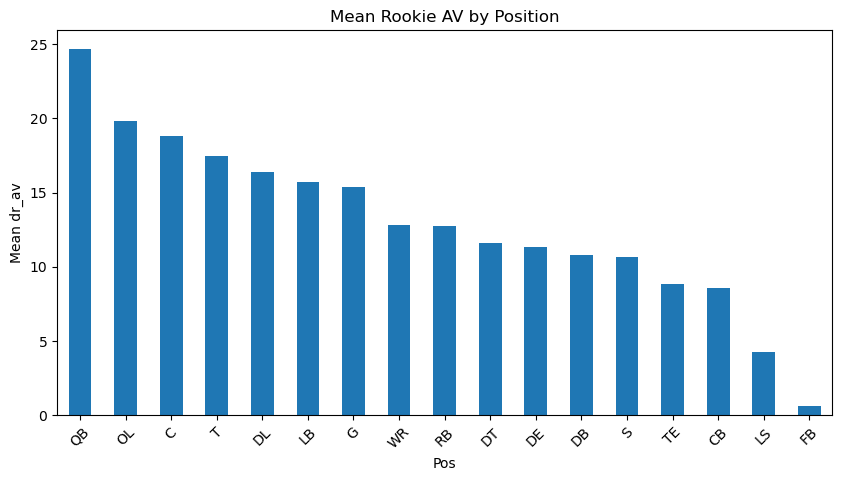

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
pos_stats["mean"].plot(kind="bar")
plt.title("Mean Rookie AV by Position")
plt.ylabel("Mean dr_av")
plt.xticks(rotation=45)
plt.show()

In [22]:

merged_df = merged_df[~merged_df["Pos"].isin(["FB", "LS"])]

print("Final position distribution:")
print(merged_df["PosGroup"].value_counts())

Final position distribution:
PosGroup
Front7    627
Skill     548
DB        407
OL        229
QB         84
Name: count, dtype: int64


In [23]:
qb_df = merged_df[merged_df["PosGroup"] == "QB"].copy()
skill_df = merged_df[merged_df["PosGroup"] == "Skill"].copy()
ol_df = merged_df[merged_df["PosGroup"] == "OL"].copy()
front7_df = merged_df[merged_df["PosGroup"] == "Front7"].copy()
db_df = merged_df[merged_df["PosGroup"] == "DB"].copy()

In [24]:
# Save datasets
qb_df.to_csv(PROCESSED_DIR / "qb_modeling_data.csv", index=False)
skill_df.to_csv(PROCESSED_DIR / "skill_modeling_data.csv", index=False)
ol_df.to_csv(PROCESSED_DIR / "ol_modeling_data.csv", index=False)
front7_df.to_csv(PROCESSED_DIR / "front7_modeling_data.csv", index=False)
db_df.to_csv(PROCESSED_DIR / "db_modeling_data.csv", index=False)

print("Saved files:")
print("- qb_modeling_data.csv")
print("- skill_modeling_data.csv")
print("- ol_modeling_data.csv")
print("- front7_modeling_data.csv")
print("- db_modeling_data.csv")

Saved files:
- qb_modeling_data.csv
- skill_modeling_data.csv
- ol_modeling_data.csv
- front7_modeling_data.csv
- db_modeling_data.csv


In [25]:
for name, df in [
    ("QB", qb_df),
    ("Skill", skill_df),
    ("OL", ol_df),
    ("Front7", front7_df),
    ("DB", db_df)
]:
    print(f"\n{name} dataset")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Mean dr_av:", round(df["dr_av"].mean(), 2))


QB dataset
Rows: 84
Columns: 50
Mean dr_av: 24.71

Skill dataset
Rows: 548
Columns: 50
Mean dr_av: 12.05

OL dataset
Rows: 229
Columns: 50
Mean dr_av: 19.4

Front7 dataset
Rows: 627
Columns: 50
Mean dr_av: 15.32

DB dataset
Rows: 407
Columns: 50
Mean dr_av: 10.46
